# K ближайших соседей (kNN) — Pima Indians Diabetes

**Метод:** kNN — непараметрический классификатор: метка нового объекта определяется голосованием k ближайших точек обучающей выборки в пространстве признаков. Не строит явную модель, чувствителен к масштабу признаков и к выбору k. Датасет Pima Indians Diabetes содержит 768 пациенток индейцев племени Пима с 8 числовыми медицинскими показателями; задача — предсказать, развился ли диабет.

## 1. Используемые библиотеки

In [11]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve,
)

## 2. Загрузка и просмотр датасета

In [12]:
df = pd.read_csv("diabetes.csv")

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

print("\nИнформация о датасете:")
print(df.info())

print("\nСтатистика:")
print(df.describe())

print("\nРаспределение Outcome:")
print(df["Outcome"].value_counts())

Размер датасета: (768, 9)

Первые 5 строк:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               76

## 3. Предварительная обработка

In [13]:
data = df.copy()

# В этих колонках 0 на самом деле означает «значение не измерено»
zero_as_nan = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
data[zero_as_nan] = data[zero_as_nan].replace(0, np.nan)

print("Пропуски после замены нулей:")
print(data.isnull().sum())

# Заполняем медианой
data[zero_as_nan] = data[zero_as_nan].fillna(data[zero_as_nan].median())

X = data.drop(columns=["Outcome"])
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# kNN основан на расстояниях — обязательно масштабируем
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train)
X_test_final  = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

Пропуски после замены нулей:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Train: (614, 8), Test: (154, 8)


## 4. Тепловая карта

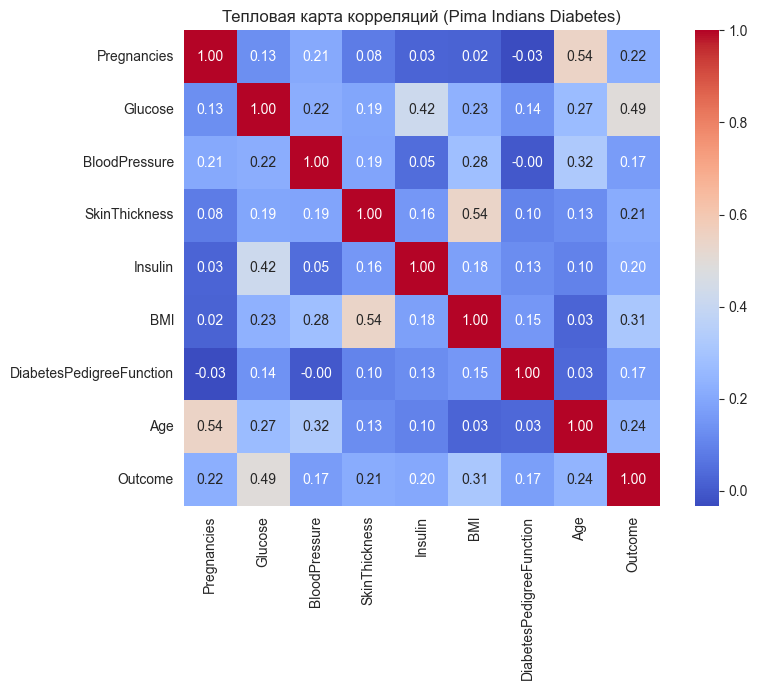

In [14]:
plt.figure(figsize=(9, 7))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Тепловая карта корреляций (Pima Indians Diabetes)")
plt.tight_layout()
plt.show()

## 5. Обучение модели

In [15]:
# Подбор k по 5-fold cross-validation
k_range = range(1, 31)
cv_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_final, y_train, cv=5, scoring="f1")
    cv_scores.append(scores.mean())

best_k = list(k_range)[int(np.argmax(cv_scores))]
print(f"Лучшее k = {best_k}, F1 на CV = {max(cv_scores):.4f}")

model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_final, y_train)

Лучшее k = 19, F1 на CV = 0.6492


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",19
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## 6. Прогнозы модели

In [16]:
y_pred  = model.predict(X_test_final)
y_proba = model.predict_proba(X_test_final)[:, 1]

print("Первые 15 прогнозов:", y_pred[:15])
print("Реальные значения:  ", y_test.values[:15])

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print(f"\nAccuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["нет диабета", "диабет"]))

Первые 15 прогнозов: [1 0 0 0 0 0 0 1 0 1 0 0 0 0 0]
Реальные значения:   [0 0 0 1 0 0 1 1 0 0 0 1 0 0 1]

Accuracy:  0.7468
Precision: 0.6667
Recall:    0.5556
F1-score:  0.6061
ROC-AUC:   0.8077

Classification report:
              precision    recall  f1-score   support

 нет диабета       0.78      0.85      0.81       100
      диабет       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



## 7. Графики выходных результатов

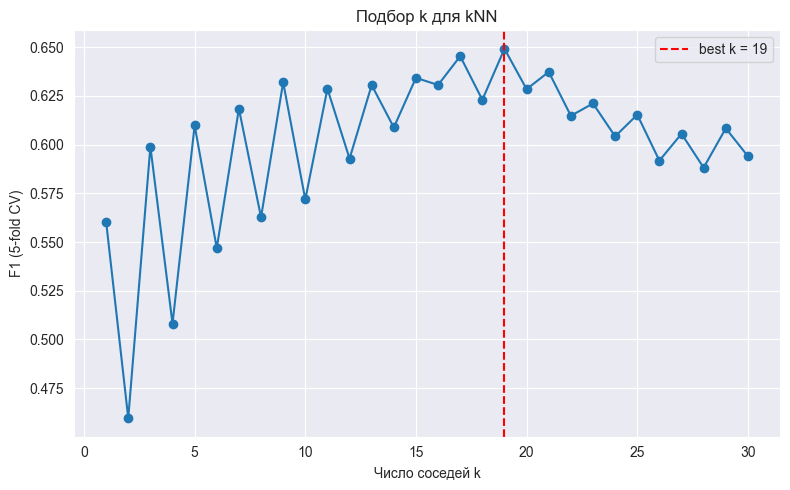

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), cv_scores, marker="o")
plt.axvline(best_k, linestyle="--", color="red", label=f"best k = {best_k}")
plt.xlabel("Число соседей k")
plt.ylabel("F1 (5-fold CV)")
plt.title("Подбор k для kNN")
plt.legend()
plt.tight_layout()
plt.show()

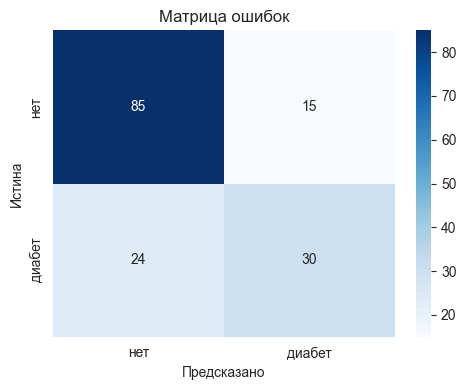

In [18]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["нет", "диабет"], yticklabels=["нет", "диабет"])
plt.xlabel("Предсказано")
plt.ylabel("Истина")
plt.title("Матрица ошибок")
plt.tight_layout()
plt.show()

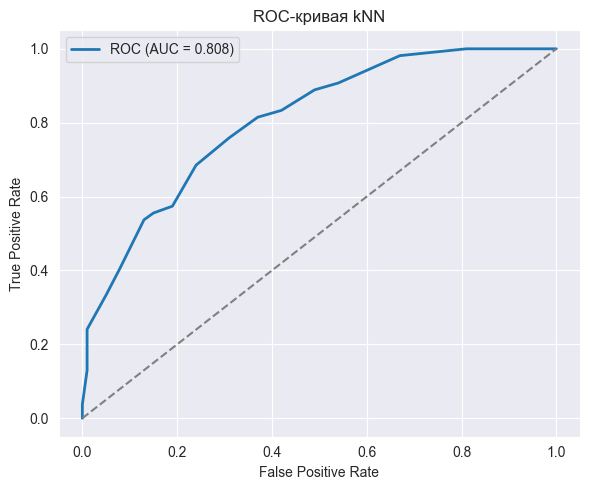

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая kNN")
plt.legend()
plt.tight_layout()
plt.show()

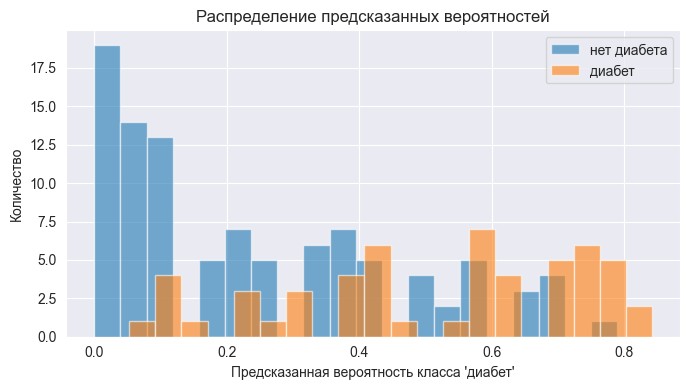

In [20]:
plt.figure(figsize=(7, 4))
plt.hist(y_proba[y_test == 0], bins=20, alpha=0.6, label="нет диабета")
plt.hist(y_proba[y_test == 1], bins=20, alpha=0.6, label="диабет")
plt.xlabel("Предсказанная вероятность класса 'диабет'")
plt.ylabel("Количество")
plt.title("Распределение предсказанных вероятностей")
plt.legend()
plt.tight_layout()
plt.show()